In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix


df = pd.read_csv("../Data/features.csv")


model = joblib.load("../models/model.pkl")

print("Testing data model")
df.head()

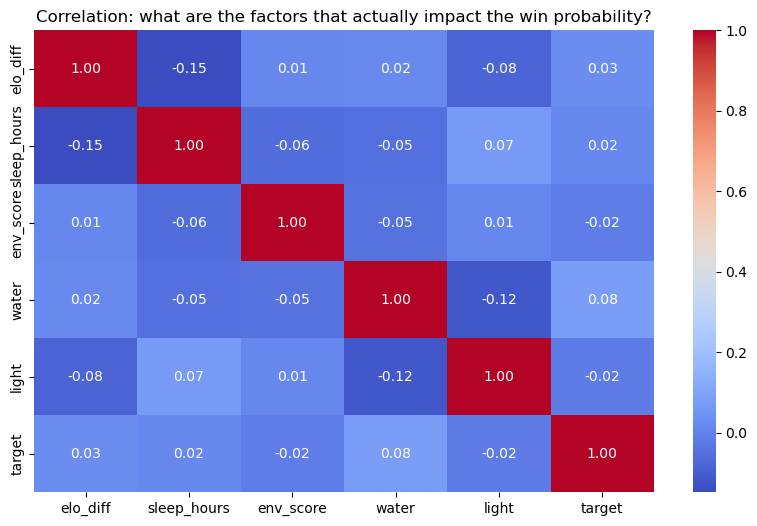

In [3]:
plt.figure(figsize=(10,6))

sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation: what are the factors that actually impact the win probability?")
plt.show()

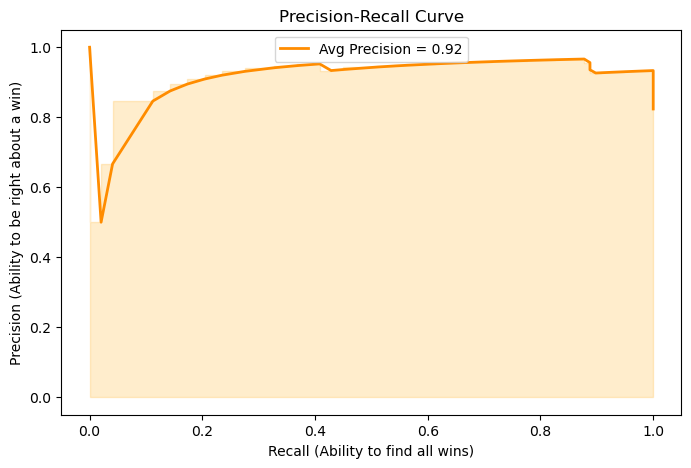

In [4]:
#assuming the model is logis, regression

y_pred_cont = model.predict(df.drop('target', axis="columns"))
y_true = (df['target'] == 1.0).astype(int)
precision, recall, _ = precision_recall_curve(y_true, y_pred_cont)
ap = average_precision_score(y_true, y_pred_cont)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='darkorange', lw=2, label=f'Avg Precision = {ap:.2f}')
plt.fill_between(recall, precision, step='post', alpha=0.2, color='orange')
plt.xlabel('Recall (Ability to find all wins)')
plt.ylabel('Precision (Ability to be right about a win)')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()

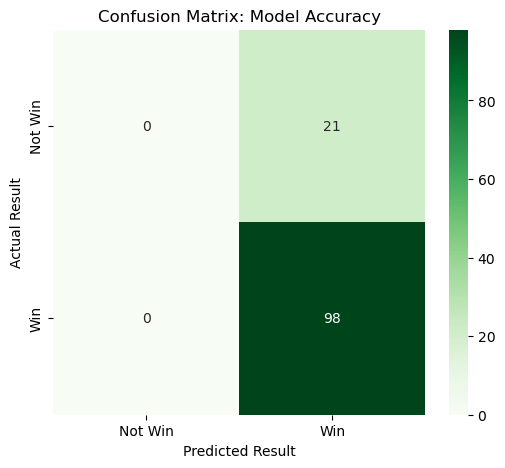

In [5]:
y_pred_binary = (y_pred_cont > 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred_binary)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Not Win', 'Win'], yticklabels=['Not Win', 'Win'])
plt.ylabel('Actual Result')
plt.xlabel('Predicted Result')
plt.title('Confusion Matrix: Model Accuracy')
plt.show()

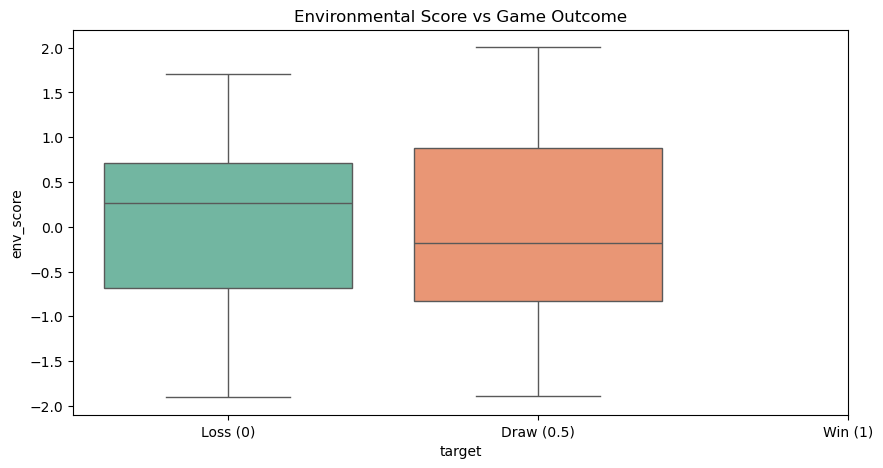

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='target', y='env_score', hue='target', palette="Set2", legend=False)
plt.xticks([0, 1, 2], ['Loss (0)', 'Draw (0.5)', 'Win (1)'])
plt.title("Environmental Score vs Game Outcome")
plt.show()